Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best Cross-Validation Score: 0.9986

--- Final Model Evaluation ---
Accuracy: 0.9994

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1117
           1       1.00      1.00      1.00       477

    accuracy                           1.00      1594
   macro avg       1.00      1.00      1.00      1594
weighted avg       1.00      1.00      1.00      1594



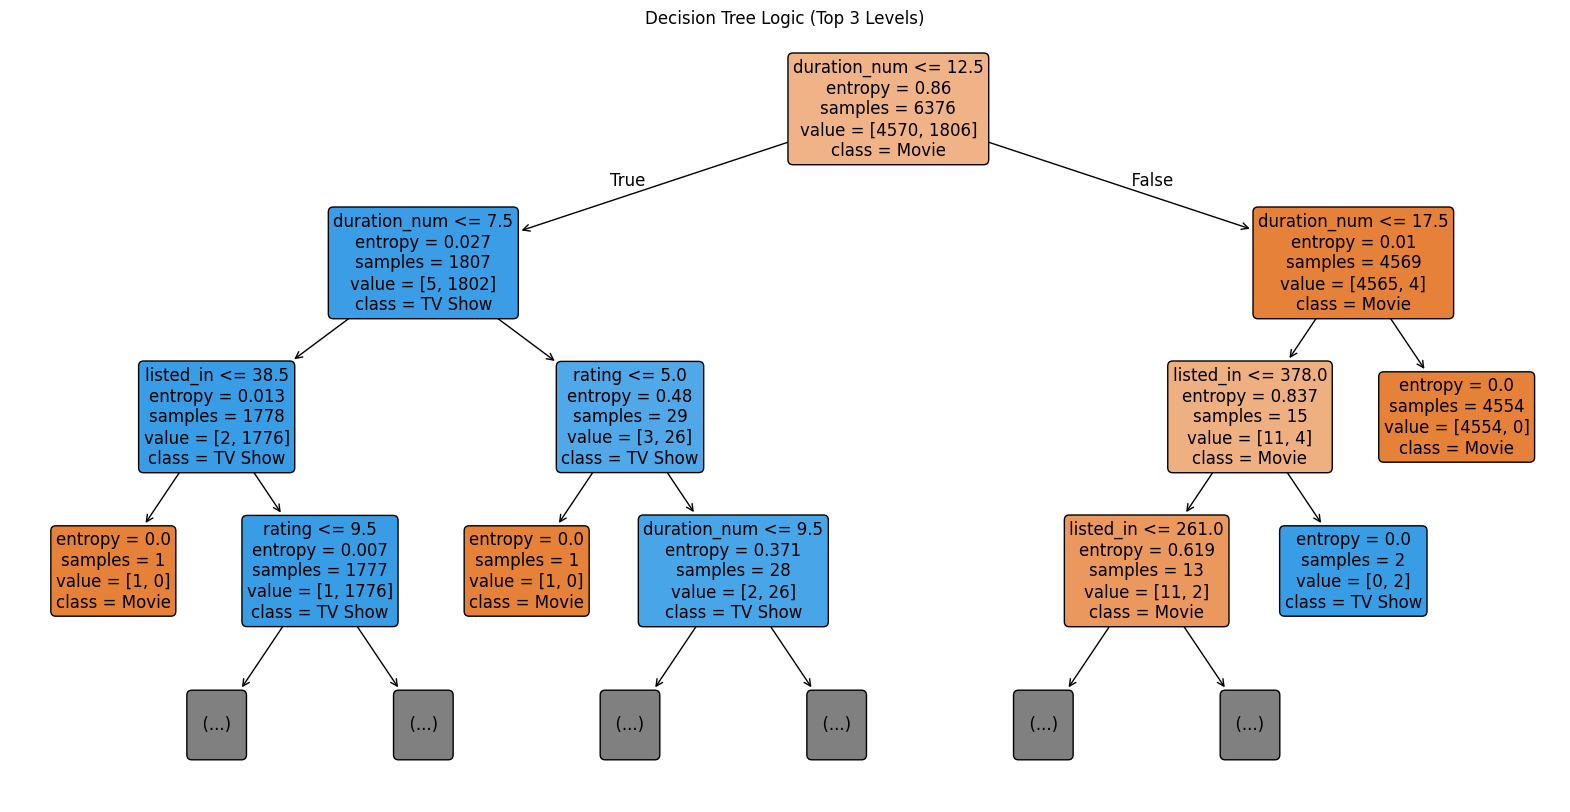

/tmp/ipython-input-2958218246.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


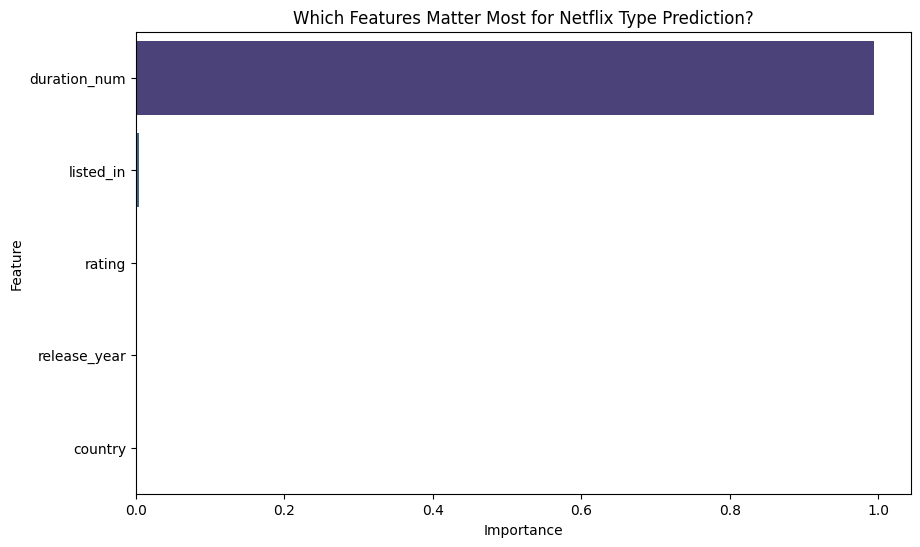

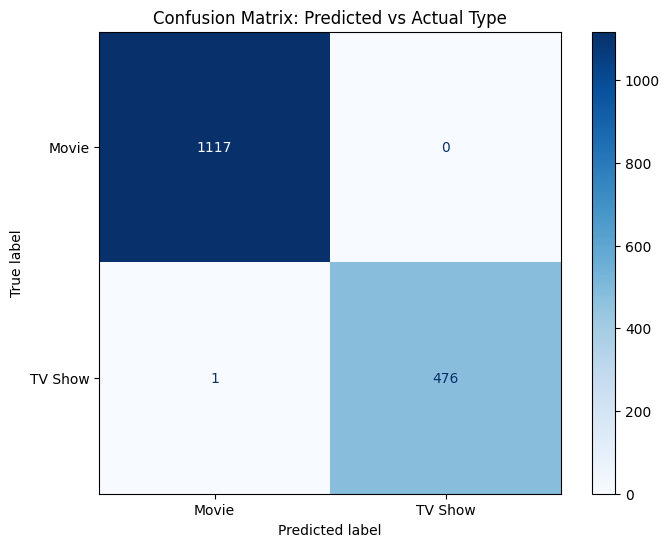

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# =============================
# LOAD NETFLIX DATASET
# =============================
df = pd.read_csv("netflix_titles.csv")

# =============================
# DATA CLEANING (Netflix Version)
# =============================

# Keep useful columns only
df = df[['type','release_year','rating','country','listed_in','duration']].copy()

# Convert duration text → numeric
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)
df.drop('duration', axis=1, inplace=True)

# Handle missing values
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

# Encode categorical features (same style as your adult.csv code)
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# =============================
# FEATURES + TARGET
# =============================
X = df.drop('type', axis=1)
y = df['type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =============================
# DECISION TREE MODEL
# =============================
dtree = DecisionTreeClassifier(random_state=42)

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

grid_search = GridSearchCV(
    estimator=dtree,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n--- Final Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =============================
# TREE VISUALIZATION
# =============================
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    best_model,
    max_depth=3,
    feature_names=X.columns,
    class_names=['Movie','TV Show'],
    filled=True,
    rounded=True,
    fontsize=12
)

plt.title("Decision Tree Logic (Top 3 Levels)")
plt.show()

# =============================
# FEATURE IMPORTANCE GRAPH
# =============================
import seaborn as sns

importances = best_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance', ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(15),   # cleaner graph
    palette='viridis'
)

plt.title('Which Features Matter Most for Netflix Type Prediction?')
plt.show()

# =============================
# CONFUSION MATRIX
# =============================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Movie','TV Show']
)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(cmap='Blues', ax=ax)

plt.title('Confusion Matrix: Predicted vs Actual Type')
plt.show()
